<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

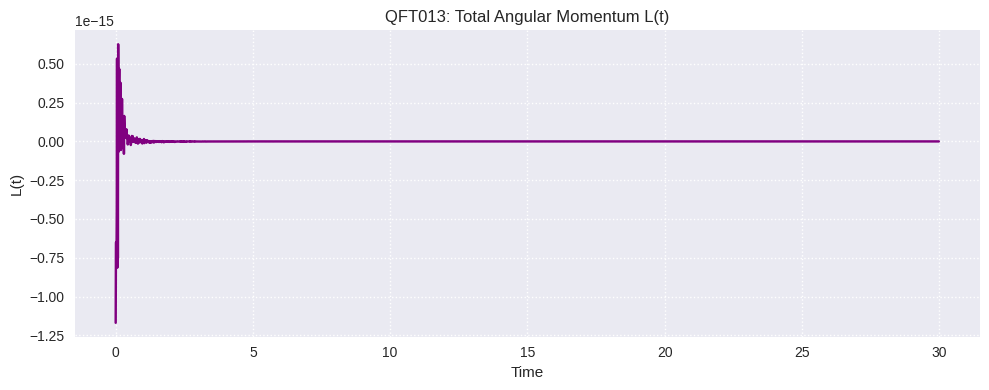

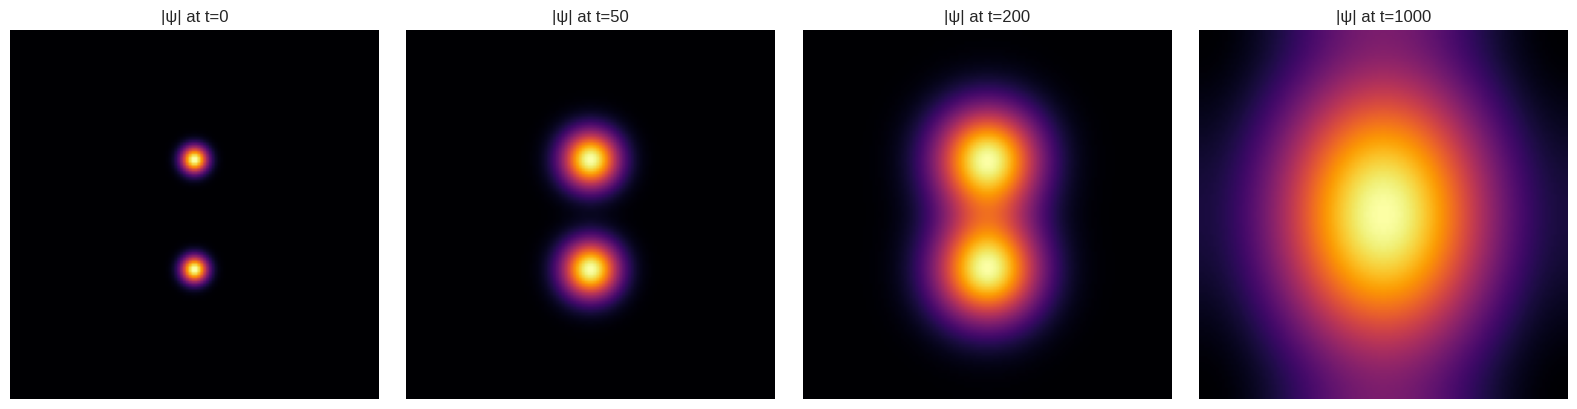

In [1]:

# QFT013: Orbital Conservation — Codex-Ready
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N_grid = 128
T = 3000
dt = 0.01
delta = 0.1
kappa = 0.1
gamma = 0.01
v0 = 0.5  # initial transverse velocity

# Grid setup
x = np.linspace(-1, 1, N_grid)
y = np.linspace(-1, 1, N_grid)
X, Y = np.meshgrid(x, y, indexing='ij')

# Initial attractors with transverse velocity
def gaussian(x0, y0, vx=0.0, vy=0.0, sigma=0.05, amp=1.0):
    phase = np.exp(1j * (vx * X + vy * Y))
    return amp * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)) * phase

psi1 = gaussian(-0.3, 0.0, vy=+v0)
psi2 = gaussian(+0.3, 0.0, vy=-v0)
psi = (psi1 + psi2).astype(np.complex128)

# FFT Laplacian kernel
kx = np.fft.fftfreq(N_grid, d=(x[1] - x[0])) * 2 * np.pi
ky = np.fft.fftfreq(N_grid, d=(y[1] - y[0])) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing='ij')
laplacian_kernel = -(KX**2 + KY**2)

# Trackers
L_t = []
snapshots = []

# Evolution loop
for t in range(T):
    # Compute angular momentum density
    grad_x = np.fft.ifft2(1j * KX * np.fft.fft2(psi))
    grad_y = np.fft.ifft2(1j * KY * np.fft.fft2(psi))
    L_density = np.real(X * grad_y - Y * grad_x) * np.abs(psi)**2
    L_total = np.sum(L_density)
    L_t.append(L_total)

    # Evolution step
    nonlinear = delta * np.abs(psi)**2 * psi
    restoring = -kappa * psi
    rhs = psi + dt * (nonlinear + restoring)

    rhs_fft = np.fft.fft2(rhs)
    denominator = 1 - dt * gamma * laplacian_kernel
    psi_fft = rhs_fft / denominator
    psi = np.fft.ifft2(psi_fft)

    if t in [0, 50, 200, 1000]:
        snapshots.append(np.abs(psi))

# Plot angular momentum over time
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 4))
plt.plot(np.arange(T) * dt, L_t, color='purple')
plt.title('QFT013: Total Angular Momentum L(t)')
plt.xlabel('Time')
plt.ylabel('L(t)')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# Plot field snapshots
fig2, axes2 = plt.subplots(1, len(snapshots), figsize=(16, 4))
for i, snap in enumerate(snapshots):
    axes2[i].imshow(snap, cmap='inferno', origin='lower')
    axes2[i].set_title(f'|ψ| at t={ [0, 50, 200, 1000][i] }')
    axes2[i].axis('off')

plt.tight_layout()
plt.show()